In [1]:
!pip install kagglehub

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'skin-cancer-mnist-ham10000' dataset.
Path to dataset files: /kaggle/input/skin-cancer-mnist-ham10000


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
import kagglehub
import os

# Define a folder in your Google Drive
drive_path = '/content/drive/MyDrive/HAM10000_Project'

# Create the folder if it doesn't exist
if not os.path.exists(drive_path):
    os.makedirs(drive_path)

# Download the dataset
# Note: kagglehub usually downloads to a cache,
# so we will move or link it to your Drive path.
path = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")

print("Dataset downloaded to temporary cache:", path)

Using Colab cache for faster access to the 'skin-cancer-mnist-ham10000' dataset.
Dataset downloaded to temporary cache: /kaggle/input/skin-cancer-mnist-ham10000


In [8]:
import pandas as pd

# This path comes from your successful download output
metadata_path = '/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_metadata.csv'

# Load the data
df = pd.read_csv(metadata_path)

# Look at the first 5 rows
df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [9]:
# Count how many of each skin lesion type exist
print(df['dx'].value_counts())

dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


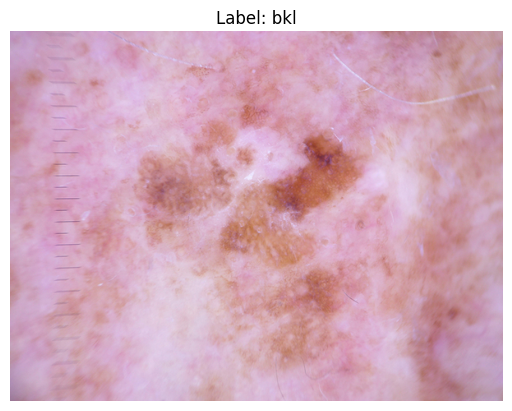

In [10]:
import matplotlib.pyplot as plt
from PIL import Image
import os

# Path to one of the image folders
image_dir = '/kaggle/input/skin-cancer-mnist-ham10000/ham10000_images_part_1/'

# Get the first image ID from your dataframe
sample_image_id = df['image_id'][0] + '.jpg'
img_path = os.path.join(image_dir, sample_image_id)

# Open and show
img = Image.open(img_path)
plt.imshow(img)
plt.title(f"Label: {df['dx'][0]}")
plt.axis('off')
plt.show()

/tmp/ipython-input-1716218854.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='lesion_name', data=df, order=df['lesion_name'].value_counts().index, palette='viridis')


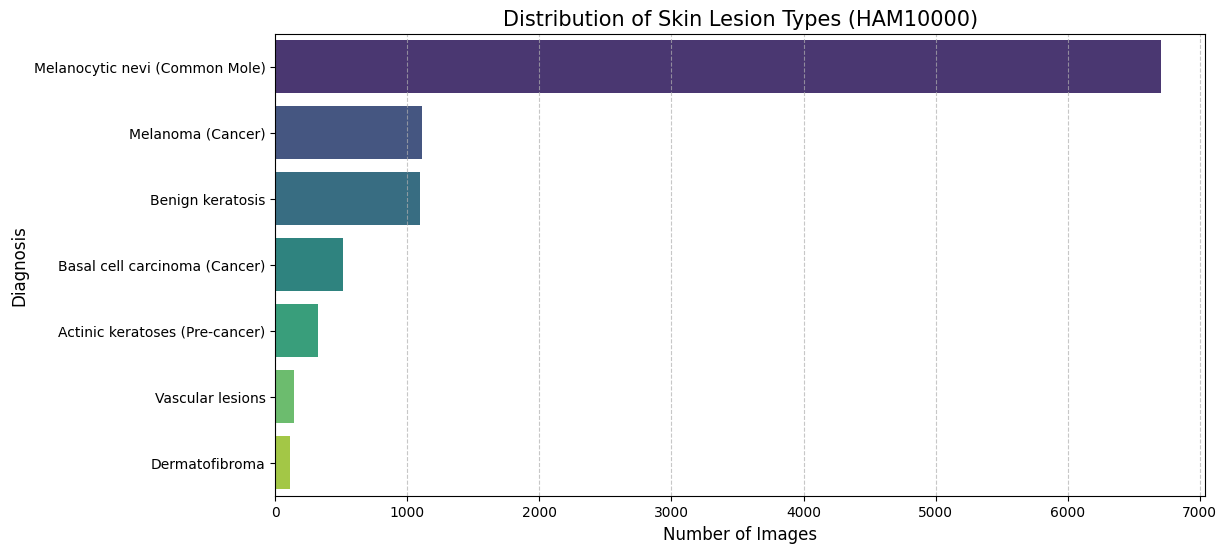

Total Images: 10015

Breakdown per category:
lesion_name
Melanocytic nevi (Common Mole)    6705
Melanoma (Cancer)                 1113
Benign keratosis                  1099
Basal cell carcinoma (Cancer)      514
Actinic keratoses (Pre-cancer)     327
Vascular lesions                   142
Dermatofibroma                     115
Name: count, dtype: int64


In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. Use the path from your previous download
# If 'path' isn't defined, copy the string from your previous output
csv_path = os.path.join(path, 'HAM10000_metadata.csv')

# 2. Load the metadata
df = pd.read_csv(csv_path)

# 3. Map the short codes to full names for readability
lesion_type_dict = {
    'nv': 'Melanocytic nevi (Common Mole)',
    'mel': 'Melanoma (Cancer)',
    'bkl': 'Benign keratosis',
    'bcc': 'Basal cell carcinoma (Cancer)',
    'akiec': 'Actinic keratoses (Pre-cancer)',
    'vasc': 'Vascular lesions',
    'df': 'Dermatofibroma'
}
df['lesion_name'] = df['dx'].map(lesion_type_dict)

# 4. Create the visualization
plt.figure(figsize=(12, 6))
sns.countplot(y='lesion_name', data=df, order=df['lesion_name'].value_counts().index, palette='viridis')

plt.title('Distribution of Skin Lesion Types (HAM10000)', fontsize=15)
plt.xlabel('Number of Images', fontsize=12)
plt.ylabel('Diagnosis', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# 5. Print the exact numbers
print("Total Images:", len(df))
print("\nBreakdown per category:")
print(df['lesion_name'].value_counts())

In [ ]:
import shutil
import os

# 1. Define where the data is now (temporary)
current_path = path

# 2. Define where you want it to live forever in your Drive
permanent_path = '/content/drive/MyDrive/HAM10000_Project_Data'

# 3. Copy the files (This may take a few minutes because the dataset is large)
if not os.path.exists(permanent_path):
    print("Moving files to Google Drive... please wait.")
    shutil.copytree(current_path, permanent_path)
    print("Success! Your data is now permanently saved in your Drive.")
else:
    print("Files already exist in your Drive.")

Moving files to Google Drive... please wait.
